In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image
import os

2024-04-01 18:27:46.760569: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-01 18:27:46.760661: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-01 18:27:47.032768: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Thermal_DATA

> **Load_data**

In [41]:
#suppose we work with Thermal
classes = {'bike': 0, 'bus': 1, 'car': 2, 'person': 3, 'sign': 4, 'motor': 5, 'light': 6, 'truck': 7}
num_2_classes = {0:'bike', 1:'bus', 2:'car', 3:'person', 4:'sign', 5:'motor', 6:'light', 7:'truck'}

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/cse-547-final-project/Train_IR/train_thermal_patches/', #path to your data
    labels='inferred',
    label_mode='int',
    class_names=list(classes.keys()),
    image_size=(64, 64), #resize the image to 64x64
    batch_size=256,
    shuffle=True,
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/cse-547-final-project/Val_IR/val_thermal_patches',
    labels='inferred',
    label_mode='int',
    class_names=list(classes.keys()),
    image_size=(64, 64),
    batch_size=256,
    shuffle=False,
)

Found 52930 files belonging to 8 classes.
Found 4927 files belonging to 8 classes.


> **Plot Samples**

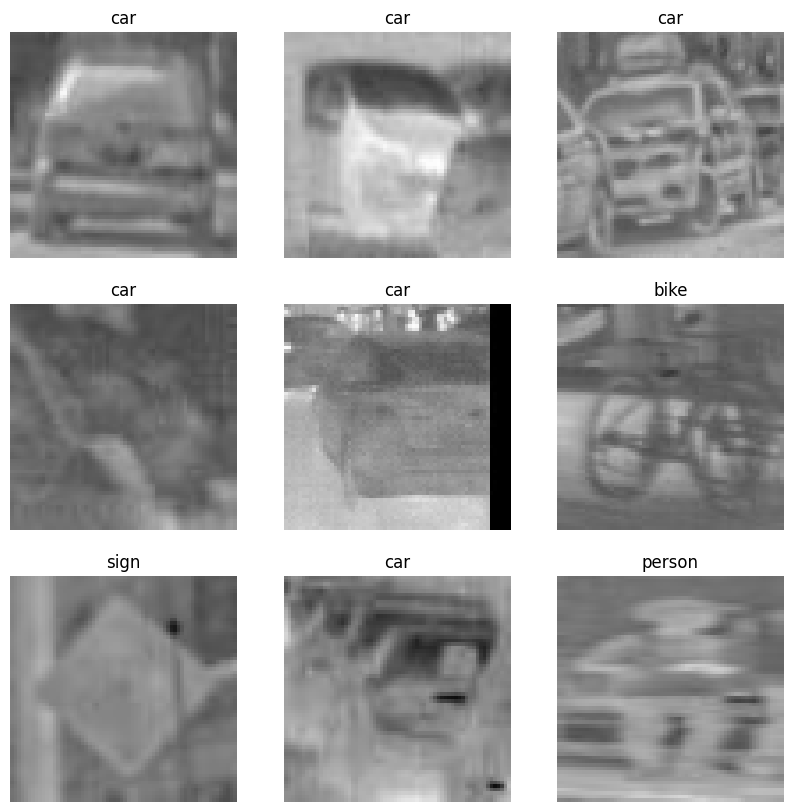

In [42]:
num_samples=9 #how many images to plot
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):  # take one batch from the dataset
    for i in range(num_samples):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  
        plt.title(num_2_classes[labels[i].numpy()]) 
        plt.axis("off")
plt.show()

> **Prepare the model**

In [43]:
from tensorflow.keras import layers, models
model = models.Sequential()

# CNN
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
#model.add(layers.MaxPooling2D((2, 2)))

# Dense
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(len(classes), activation='softmax')) 

# Compile the model
model.compile(optimizer='adamw',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 58, 58, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 430592)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │    27,557,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,651,720 (105.48 MB)

 Trainable params: 27,651,720 (105.48 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

for layer in vgg_base.layers:
    layer.trainable = True

vgg16 = models.Sequential()
vgg16.add(vgg_base)
vgg16.add(layers.Flatten())
vgg16.add(layers.Dense(64, activation='relu'))
vgg16.add(layers.Dense(len(classes), activation='softmax'))

# Compile the model
vgg16.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

vgg16.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

> **Train_Validate the model**

In [45]:
history = model.fit(train_dataset, epochs=5, validation_data=val_dataset,verbose=1)

Epoch 1/5
  1/207 ━━━━━━━━━━━━━━━━━━━━ 12:06 4s/step - accuracy: 0.2539 - loss: 26.0521

W0000 00:00:1711999277.614322      92 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.6248 - loss: 212.4141

W0000 00:00:1711999306.384507      95 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1711999307.023393      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


207/207 ━━━━━━━━━━━━━━━━━━━━ 35s 152ms/step - accuracy: 0.6249 - loss: 211.6241 - val_accuracy: 0.6399 - val_loss: 1.3556
Epoch 2/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 31s 146ms/step - accuracy: 0.6582 - loss: 1.1965 - val_accuracy: 0.7116 - val_loss: 0.9969
Epoch 3/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 31s 148ms/step - accuracy: 0.7632 - loss: 0.7603 - val_accuracy: 0.7668 - val_loss: 0.8323
Epoch 4/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 31s 147ms/step - accuracy: 0.8036 - loss: 0.6093 - val_accuracy: 0.7903 - val_loss: 0.7975
Epoch 5/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 32s 150ms/step - accuracy: 0.8320 - loss: 0.5103 - val_accuracy: 0.8121 - val_loss: 0.7438


In [46]:
history1 = vgg16.fit(train_dataset, epochs=5, validation_data=val_dataset,verbose=1)

Epoch 1/5


W0000 00:00:1711999441.220391      92 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


206/207 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5699 - loss: 4.4210

W0000 00:00:1711999494.067976      95 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5702 - loss: 4.4082

W0000 00:00:1711999495.072866      92 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


207/207 ━━━━━━━━━━━━━━━━━━━━ 62s 272ms/step - accuracy: 0.5705 - loss: 4.3955 - val_accuracy: 0.7808 - val_loss: 0.7892
Epoch 2/5


W0000 00:00:1711999497.453614      92 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


207/207 ━━━━━━━━━━━━━━━━━━━━ 54s 258ms/step - accuracy: 0.8055 - loss: 0.6476 - val_accuracy: 0.8831 - val_loss: 0.4648
Epoch 3/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 55s 259ms/step - accuracy: 0.8763 - loss: 0.4008 - val_accuracy: 0.9249 - val_loss: 0.3175
Epoch 4/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 54s 259ms/step - accuracy: 0.9145 - loss: 0.2709 - val_accuracy: 0.9178 - val_loss: 0.3250
Epoch 5/5
207/207 ━━━━━━━━━━━━━━━━━━━━ 55s 260ms/step - accuracy: 0.9264 - loss: 0.2312 - val_accuracy: 0.9042 - val_loss: 0.3402


In [47]:
vgg_preds = vgg16.predict(val_dataset)
vgg_labels = vgg_preds.argmax(axis=1)

 3/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step 

W0000 00:00:1711999716.211307      92 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step


W0000 00:00:1711999718.759987      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [48]:
true_labels = []
class_names = val_dataset.class_names

for images, labels in val_dataset:
    true_labels.extend(labels.numpy())

In [49]:
misclassified_indices = []

for i, (true_label, predicted_label) in enumerate(zip(true_labels, vgg_labels)):
    if true_label != predicted_label:
        misclassified_indices.append(i)

print("len Misclassified indices:", len(misclassified_indices))

len Misclassified indices: 472


In [50]:
patches_df= pd.read_csv('/kaggle/input/patches-info/patches_thermal_val_info.csv')

In [51]:
patches_df

,patch_filename,original_filename,class,bbox,image_id
0,video-JhYLiFCieHQHaY8o7-frame-000000-xT7BXRKKy...,data/video-JhYLiFCieHQHaY8o7-frame-000000-xT7B...,car,"[237, 189, 101, 100]",654
1,video-JhYLiFCieHQHaY8o7-frame-000000-xT7BXRKKy...,data/video-JhYLiFCieHQHaY8o7-frame-000000-xT7B...,car,"[107, 203, 69, 52]",654
2,video-JhYLiFCieHQHaY8o7-frame-000600-54cr88GJs...,data/video-JhYLiFCieHQHaY8o7-frame-000600-54cr...,sign,"[445, 143, 33, 32]",656
3,video-JhYLiFCieHQHaY8o7-frame-000900-pdb96S7B7...,data/video-JhYLiFCieHQHaY8o7-frame-000900-pdb9...,car,"[560, 228, 79, 37]",657
4,video-JhYLiFCieHQHaY8o7-frame-000900-pdb96S7B7...,data/video-JhYLiFCieHQHaY8o7-frame-000900-pdb9...,car,"[417, 232, 44, 22]",657
...,...,...,...,...,...
4922,video-mKfYgxHA8ZZmXvw56-frame-010325-LTyWq3oXG...,data/video-mKfYgxHA8ZZmXvw56-frame-010325-LTyW...,car,"[0, 251, 66, 35]",5929
4923,video-mKfYgxHA8ZZmXvw56-frame-010325-LTyWq3oXG...,data/video-mKfYgxHA8ZZmXvw56-frame-010325-LTyW...,car,"[38, 249, 60, 32]",5929
4924,video-mKfYgxHA8ZZmXvw56-frame-010325-LTyWq3oXG...,data/video-mKfYgxHA8ZZmXvw56-frame-010325-LTyW...,car,"[171, 255, 56, 38]",5929
4925,video-mKfYgxHA8ZZmXvw56-frame-010325-LTyWq3oXG...,data/video-mKfYgxHA8ZZmXvw56-frame-010325-LTyW...,car,"[268, 244, 35, 28]",5929


/kaggle/input/cse-547-final-project/Val_IR/val_thermal_patches/bike/video-k5bTJAiyEgHismN7Y-frame-006936-SDyxnfAzpe8qCukix_16152.jpg
video-k5bTJAiyEgHismN7Y-frame-006936-SDyxnfAzpe8qCukix_16152.jpg
patch_filename       video-k5bTJAiyEgHismN7Y-frame-006936-SDyxnfAzp...
original_filename    data/video-k5bTJAiyEgHismN7Y-frame-006936-SDyx...
class                                                             bike
bbox                                                  [0, 207, 37, 58]
image_id                                                          5882
Name: 4712, dtype: object


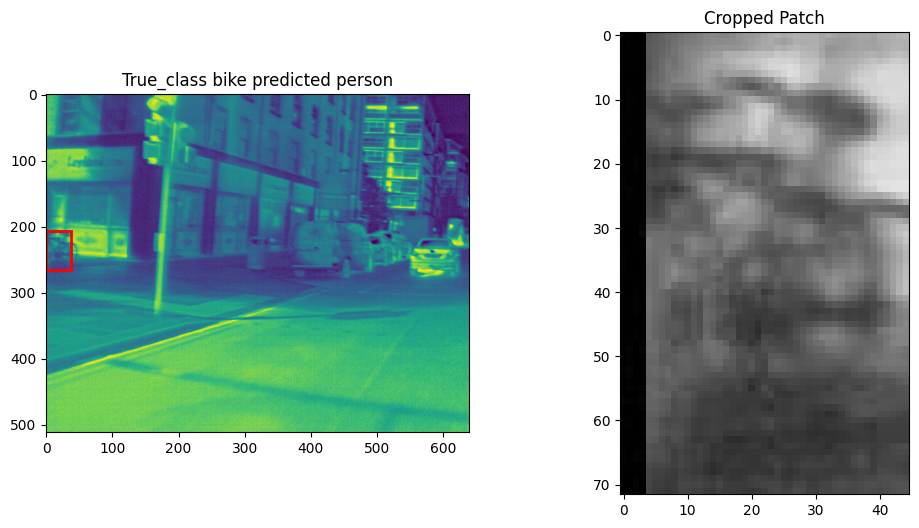

In [53]:
file_path = val_dataset.file_paths[misclassified_indices[1]] 
print(file_path)
patch_filename = os.path.basename(file_path)
print(patch_filename)
# Lookup the original image and bbox using the patch filename
row = patches_df[patches_df['patch_filename'] == patch_filename].iloc[0]
print(row)
original_img_path = os.path.join('/kaggle/input/cse-547-final-project/Val_IR', row['original_filename'])
bbox = eval(str(row['bbox']))

# Load images
original_img = Image.open(original_img_path)
patch_img = Image.open(file_path)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)

ax[0].set_title('True_class {} predicted {}'.format(row['class'],num_2_classes[vgg_labels[misclassified_indices[1]]]))
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)

ax[1].imshow(patch_img)
ax[1].set_title('Cropped Patch')

plt.show()

# RGB_DATA

In [26]:
#suppose we work with RGB
classes = {'bike': 0, 'bus': 1, 'car': 2, 'person': 3, 'sign': 4, 'motor': 5, 'light': 6, 'truck': 7}
num_2_classes = {0:'bike', 1:'bus', 2:'car', 3:'person', 4:'sign', 5:'motor', 6:'light', 7:'truck'}

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/cse-547-final-project/Train_RGB/train_rgb_patches', #path to your data
    labels='inferred',
    label_mode='int',
    class_names=list(classes.keys()),
    image_size=(64, 64), #resize the image to 64x64
    batch_size=256,
    shuffle=True,
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    '/kaggle/input/cse-547-final-project/Val_RGB/val_rgb_patches',
    labels='inferred',
    label_mode='int',
    class_names=list(classes.keys()),
    image_size=(64, 64),
    batch_size=256,
    shuffle=False,
)

Found 108297 files belonging to 8 classes.
Found 10956 files belonging to 8 classes.


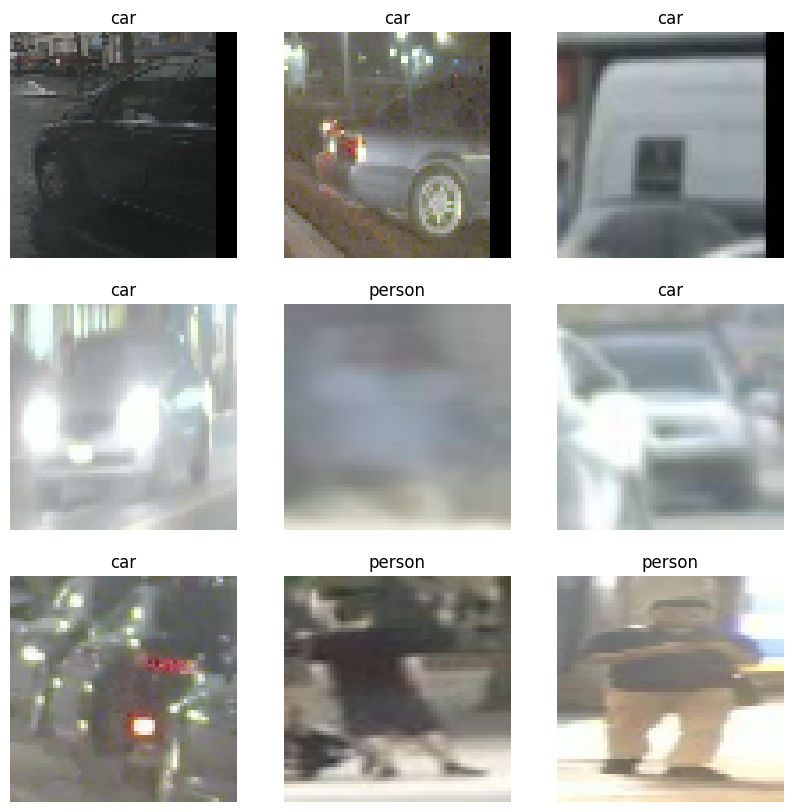

In [27]:
num_samples=9 #how many images to plot
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):  # take one batch from the dataset
    for i in range(num_samples):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))  
        plt.title(num_2_classes[labels[i].numpy()]) 
        plt.axis("off")
plt.show()

In [28]:
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

for layer in vgg_base.layers:
    layer.trainable = True

vgg16 = models.Sequential()
vgg16.add(vgg_base)
vgg16.add(layers.Flatten())
vgg16.add(layers.Dense(64, activation='relu'))
vgg16.add(layers.Dense(len(classes), activation='softmax'))

# Compile the model
vgg16.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

vgg16.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ ?                      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history2 = vgg16.fit(train_dataset, epochs=5, validation_data=val_dataset,verbose=1)

Epoch 1/5


W0000 00:00:1711998434.054063      95 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


424/424 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5543 - loss: 2.4040

W0000 00:00:1711998539.181759      93 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1711998539.986350      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


424/424 ━━━━━━━━━━━━━━━━━━━━ 117s 262ms/step - accuracy: 0.5545 - loss: 2.4015 - val_accuracy: 0.4721 - val_loss: 1.3864
Epoch 2/5


W0000 00:00:1711998545.073268      94 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


424/424 ━━━━━━━━━━━━━━━━━━━━ 112s 261ms/step - accuracy: 0.7668 - loss: 0.7614 - val_accuracy: 0.8898 - val_loss: 0.4012
Epoch 3/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 113s 265ms/step - accuracy: 0.8931 - loss: 0.3429 - val_accuracy: 0.9201 - val_loss: 0.2549
Epoch 4/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 113s 262ms/step - accuracy: 0.9131 - loss: 0.2773 - val_accuracy: 0.9134 - val_loss: 0.2922
Epoch 5/5
424/424 ━━━━━━━━━━━━━━━━━━━━ 142s 264ms/step - accuracy: 0.9340 - loss: 0.2107 - val_accuracy: 0.9252 - val_loss: 0.2736


In [30]:
vgg_preds = vgg16.predict(val_dataset)
vgg_labels = vgg_preds.argmax(axis=1)

 3/43 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step

W0000 00:00:1711999028.425267      93 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step


W0000 00:00:1711999032.967179      93 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


In [31]:
true_labels = []

for images, labels in val_dataset:
    true_labels.extend(labels.numpy())

In [32]:
vgg_labels

array([0, 0, 0, ..., 2, 4, 7])

In [33]:
class_names = val_dataset.class_names
print(class_names)

['bike', 'bus', 'car', 'person', 'sign', 'motor', 'light', 'truck']


In [34]:
import numpy as np
misclassified_indices = np.where(true_labels != vgg_labels)[0]

print("len Misclassified indices:", len(misclassified_indices))

len Misclassified indices: 820


In [35]:
misclassified_indices[0]

3

In [36]:
patches_df= pd.read_csv('/kaggle/input/patches-info/patches_rgb_val_info.csv')

/kaggle/input/cse-547-final-project/Val_RGB/val_rgb_patches/bike/video-7cJxWPFMvPdSiWASY-frame-002312-vYL6ZhtzNzGEXzq78_15732.jpg
video-7cJxWPFMvPdSiWASY-frame-002312-vYL6ZhtzNzGEXzq78_15732.jpg
patch_filename       video-7cJxWPFMvPdSiWASY-frame-002312-vYL6ZhtzN...
original_filename    data/video-7cJxWPFMvPdSiWASY-frame-002312-vYL6...
class                                                             bike
bbox                                               [172, 465, 91, 121]
image_id                                                          5566
Name: 10421, dtype: object


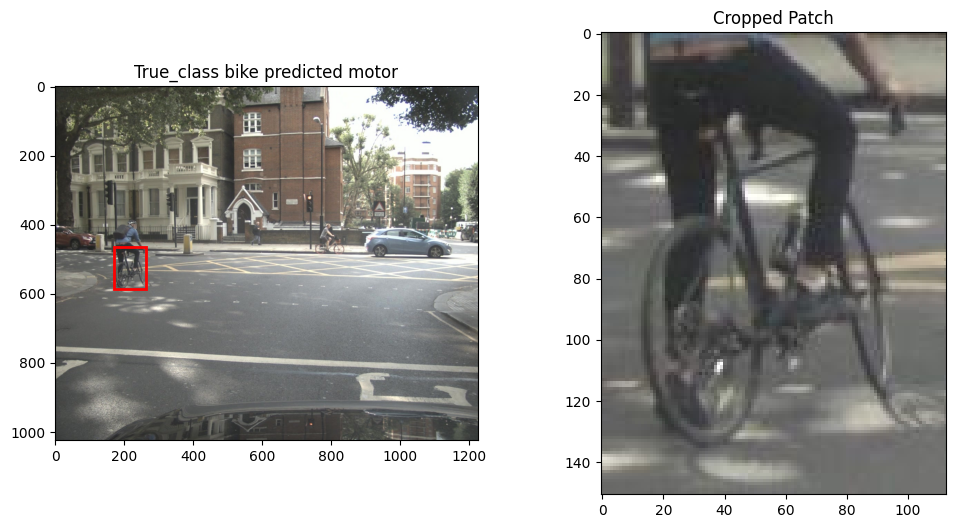

In [40]:
file_path = val_dataset.file_paths[misclassified_indices[0]] 
print(file_path)
patch_filename = os.path.basename(file_path)
print(patch_filename)
# Lookup the original image and bbox using the patch filename
row = patches_df[patches_df['patch_filename'] == patch_filename].iloc[0]
print(row)
original_img_path = os.path.join('/kaggle/input/cse-547-final-project/Val_RGB', row['original_filename'])
bbox = eval(str(row['bbox']))

# Load images
original_img = Image.open(original_img_path)
patch_img = Image.open(file_path)

# Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(original_img)

ax[0].set_title('True_class {} predicted {}'.format(class_names[true_labels[misclassified_indices[0]]],class_names[vgg_labels[misclassified_indices[0]]]))
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)

ax[1].imshow(patch_img)
ax[1].set_title('Cropped Patch')

plt.show()